In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**display first few rows**

In [43]:
project=pd.read_excel('Project123.xlsx')
print(project.head())

   Row ID        Order ID  Year Order Date  Ship Date       Ship Mode  \
0    9169  CA-2013-140571  2013 2013-03-16 2013-03-20  Standard Class   
1    6489  CA-2012-120621  2011 2012-03-21 2012-03-26  Standard Class   
2    5669  CA-2013-142405  2012 2013-06-12 2013-06-16  Standard Class   
3    2948  CA-2014-169859  2013 2014-12-15 2014-12-19  Standard Class   
4    8522  CA-2013-141887  2014 2013-01-11 2013-01-15  Standard Class   

  Customer ID   Customer Name      Segment        Country  ... Region  \
0    SJ-20125   Sanjit Jacobs  Home Office  United States  ...  South   
1    JW-16075      Julia West     Consumer  United States  ...  South   
2    SE-20110    Sanjit Engle     Consumer  United States  ...   West   
3    MP-18175  Mike Pelletier  Home Office  United States  ...   West   
4    MP-17470     Mark Packer  Home Office  United States  ...   East   

        Product ID         Category Sub-Category  \
0  OFF-PA-10001954  Office Supplies        Paper   
1  OFF-PA-10002254

In [44]:
#check project shape,column
print(project.shape)

(9994, 23)


In [45]:
#info() and describe()
print(project.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Year           9994 non-null   int64         
 3   Order Date     9994 non-null   datetime64[ns]
 4   Ship Date      9994 non-null   datetime64[ns]
 5   Ship Mode      9994 non-null   object        
 6   Customer ID    9994 non-null   object        
 7   Customer Name  9994 non-null   object        
 8   Segment        9994 non-null   object        
 9   Country        9994 non-null   object        
 10  City           9994 non-null   object        
 11  State          9994 non-null   object        
 12  Postal Code    9994 non-null   int64         
 13  Region         9994 non-null   object        
 14  Product ID     9994 non-null   object        
 15  Category       9994 n

In [46]:
#check null value use df.isnull().sum()
print(project.isnull().sum())

Row ID           0
Order ID         0
Year             0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Profit margin    0
dtype: int64


In [47]:
#check for dulicate value use df.duplicate().sum()
print(project.duplicated().sum())

0


In [48]:
print(project.isin([np.inf,-np.inf]))

      Row ID  Order ID   Year  Order Date  Ship Date  Ship Mode  Customer ID  \
0      False     False  False       False      False      False        False   
1      False     False  False       False      False      False        False   
2      False     False  False       False      False      False        False   
3      False     False  False       False      False      False        False   
4      False     False  False       False      False      False        False   
...      ...       ...    ...         ...        ...        ...          ...   
9989   False     False  False       False      False      False        False   
9990   False     False  False       False      False      False        False   
9991   False     False  False       False      False      False        False   
9992   False     False  False       False      False      False        False   
9993   False     False  False       False      False      False        False   

      Customer Name  Segment  Country  

# Data Cleaning

In [49]:
#handling missing value
print(project.dropna(inplace=True))

None


In [50]:
#remove duplicate
print(project.drop_duplicates(inplace=True))

None


# Feature Engineering

In [10]:
project['Delivery Time'] = (project['Ship Date'] - project['Order Date']).dt.days


In [11]:
project['Profit Margin'] = project['Profit'] / project['Sales']


# Exploratory Data Analysis (EDA)

In [12]:
#number of customer in state
sale=project.groupby("State")["Customer Name"].count()
print(sale)

State
Alabama                   61
Arizona                  224
Arkansas                  60
California              2001
Colorado                 182
Connecticut               82
Delaware                  96
District of Columbia      10
Florida                  383
Georgia                  184
Idaho                     21
Illinois                 492
Indiana                  149
Iowa                      30
Kansas                    24
Kentucky                 139
Louisiana                 42
Maine                      8
Maryland                 105
Massachusetts            135
Michigan                 255
Minnesota                 89
Mississippi               53
Missouri                  66
Montana                   15
Nebraska                  38
Nevada                    39
New Hampshire             27
New Jersey               130
New Mexico                37
New York                1128
North Carolina           249
North Dakota               7
Ohio                     469
Oklahoma

In [13]:
#total order in each region
region=project.groupby("Region")["Customer Name"].count()
print(region)

Region
Central    2323
East       2848
South      1620
West       3203
Name: Customer Name, dtype: int64


In [14]:
#maximum product in each region
maximum_product=project.loc[project.groupby("Region")["Sales"].idxmax(),["Customer Name","Product Name","Sales"]]
print(maximum_product)

     Customer Name                                       Product Name  \
2858  Tamara Chand              Canon imageCLASS 2200 Advanced Copier   
4024  Tom Ashbrook              Canon imageCLASS 2200 Advanced Copier   
1727   Sean Miller  Cisco TelePresence System EX90 Videoconferenci...   
4026  Raymond Buch              Canon imageCLASS 2200 Advanced Copier   

          Sales  
2858  17499.950  
4024  11199.968  
1727  22638.480  
4026  13999.960  


In [15]:
#total number of order above average

average=project["Sales"].mean()
print(average)
total_number=(project["Sales"]>average).count()
print(total_number)

229.85800083049827
9994


In [16]:
#number of sale greather than 1000 in each region
average=project["Sales"].mean()
total_sale=project[project["Sales"]>average].groupby("Region").size()
print(total_sale)

Region
Central    529
East       676
South      387
West       768
dtype: int64


In [17]:
#total order in each category
category=project.groupby("Category").size()
print(category)

Category
Furniture          2121
Office Supplies    6026
Technology         1847
dtype: int64


In [18]:
#total sales and profit in each category sub category

total_sale = project.groupby(["Category","Sub-Category"])[["Sales", "Profit"]].sum().reset_index()
print(total_sale)


           Category Sub-Category        Sales      Profit
0         Furniture    Bookcases  114879.9963  -3472.5560
1         Furniture       Chairs  328449.1030  26590.1663
2         Furniture  Furnishings   91705.1640  13059.1436
3         Furniture       Tables  206965.5320 -17725.4811
4   Office Supplies   Appliances  107532.1610  18138.0054
5   Office Supplies          Art   27118.7920   6527.7870
6   Office Supplies      Binders  203412.7330  30221.7633
7   Office Supplies    Envelopes   16476.4020   6964.1767
8   Office Supplies    Fasteners    3024.2800    949.5182
9   Office Supplies       Labels   12486.3120   5546.2540
10  Office Supplies        Paper   78479.2060  34053.5693
11  Office Supplies      Storage  223843.6080  21278.8264
12  Office Supplies     Supplies   46673.5380  -1189.0995
13       Technology  Accessories  167380.3180  41936.6357
14       Technology      Copiers  149528.0300  55617.8249
15       Technology     Machines  189238.6310   3384.7569
16       Techn

In [19]:
#total profit and sum of each month and year
project['Order Date']=pd.to_datetime(project["Order Date"])
project['Month'] = project['Order Date'].dt.to_period('M')
month=project.groupby('Month')[["Sales","Profit"]].sum()
print(month.sort_values(by=["Sales","Profit"],ascending=False))

               Sales      Profit
Month                           
2014-11  112326.4710   9682.5519
2013-12   97237.4170  17902.7301
2014-09   90488.7220  11395.4394
2014-12   90474.6008   8532.8680
2013-11   82192.3228   4376.0694
2011-09   81777.3508   8328.0994
2011-11   78628.7167   9292.1269
2014-10   77793.7552   9440.6608
2012-11   75972.5635  12474.7884
2012-12   74919.5212   8016.9659
2013-09   72908.1089   9360.4910
2011-12   69545.6205   8983.5699
2012-09   64595.9180   8209.1627
2014-08   61516.0860   8894.4486
2013-05   56691.0770   8627.4764
2013-10   56463.1300  15763.3797
2011-03   55691.0090    498.7299
2014-03   53908.9620  12957.8999
2013-03   51186.2170   3625.2715
2014-07   48428.3650   6623.5571
2014-06   48259.7487   8087.6684
2014-05   45651.2362   6274.4578
2014-01   44703.1420   7208.6826
2014-04   40112.4209   2803.6308
2013-06   39430.4430   4499.5845
2013-04   39248.5930   2957.8446
2012-03   38466.7960   9724.6724
2013-07   38440.7550   4464.6602
2012-08   

In [20]:
top_product=project.loc[project["Sales"].idxmax(),["Product Name","Sales"]]
print(top_product)

Product Name    Cisco TelePresence System EX90 Videoconferenci...
Sales                                                    22638.48
Name: 1727, dtype: object


In [21]:
#category with highest progit
category_profit = project.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [22]:
#subcategory with highest progit
sub_category = project.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(sub_category)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


# Outlier detection and removel

In [53]:
print(project.describe())

            Row ID         Year                     Order Date  \
count  9994.000000  9994.000000                           9994   
mean   4997.500000  2012.722934  2013-04-30 19:20:02.401441024   
min       1.000000  2011.000000            2011-01-04 00:00:00   
25%    2499.250000  2012.000000            2012-05-23 00:00:00   
50%    4997.500000  2013.000000            2013-06-27 00:00:00   
75%    7495.750000  2014.000000            2014-05-15 00:00:00   
max    9994.000000  2014.000000            2014-12-31 00:00:00   
std    2885.163629     1.124039                            NaN   

                           Ship Date   Postal Code         Sales     Quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2013-05-04 18:20:49.229537536  55190.379428    229.858001     3.789574   
min              2011-01-08 00:00:00   1040.000000      0.444000     1.000000   
25%              2012-05-27 00:00:00  23223.000000     17.280000     2.000000   


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Row ID'),
  Text(1, 0, 'Year'),
  Text(2, 0, 'Postal Code'),
  Text(3, 0, 'Sales'),
  Text(4, 0, 'Quantity'),
  Text(5, 0, 'Discount'),
  Text(6, 0, 'Profit'),
  Text(7, 0, 'Profit margin')])

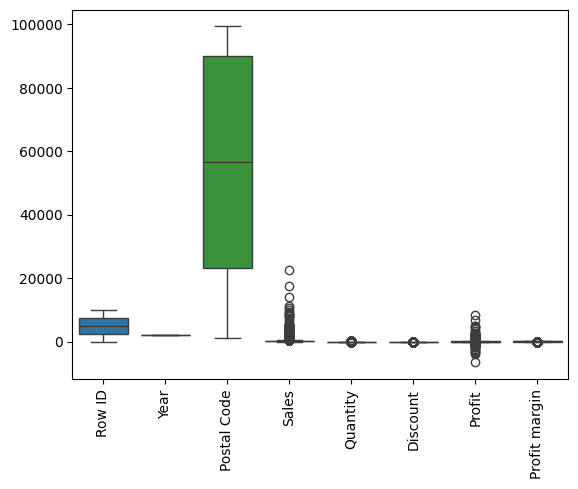

In [153]:
df=pd.read_excel('Project123.xlsx')
sns.boxplot(data=df)
plt.xticks(rotation=90)



In [187]:
#Z-score to detect outlier
mean=df["Sales"].mean()
std=df["Sales"].std()
upper_limit=mean+3*std
lower_limit=mean-3*std
total_number=df.loc[(df["Sales"]>=upper_limit)|(df["Sales"]<=lower_limit)]
print(len(total_number))

127


9867


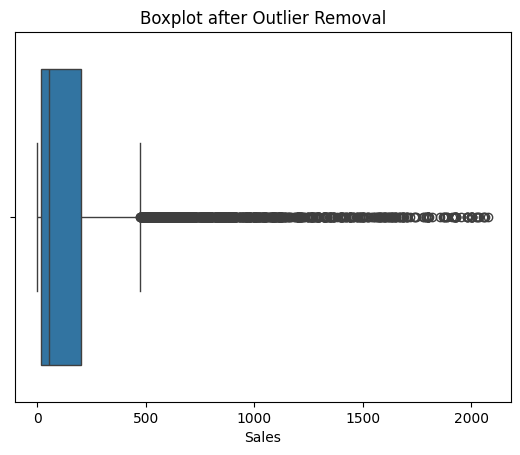

In [189]:
#Z-score outlier removel
newdf=df.loc[(df["Sales"]<upper_limit)&(df["Sales"]>lower_limit)]
print(len(newdf))
sns.boxplot(x=newdf['Sales'])
plt.title("Boxplot after Outlier Removal")
plt.xlabel("Sales")
plt.show()

In [190]:
#IQR method outlier detection
Q1=df["Sales"].quantile(0.25)
Q3=df["Sales"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
total=df.loc[(df["Sales"]>=upper_limit)&(df["Sales"]<=lower_limit)]
print(len(total))

0


In [191]:
#IQR method outlier correction
#trimming method to remove outlier

newdf=df.loc[(df["Sales"]<upper_limit)|(df["Sales"]>lower_limit)]
print(len(newdf))

9994


In [192]:
newdf=df.loc[(df["Sales"]<upper_limit)|(df["Sales"]>lower_limit)]
print(len(newdf))

9994


<Axes: ylabel='Profit'>

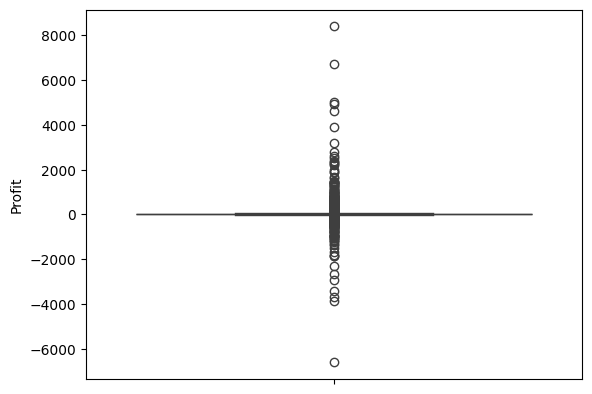

In [193]:
sns.boxplot(newdf["Profit"])

## outlier removed in Sales column

<Axes: ylabel='Sales'>

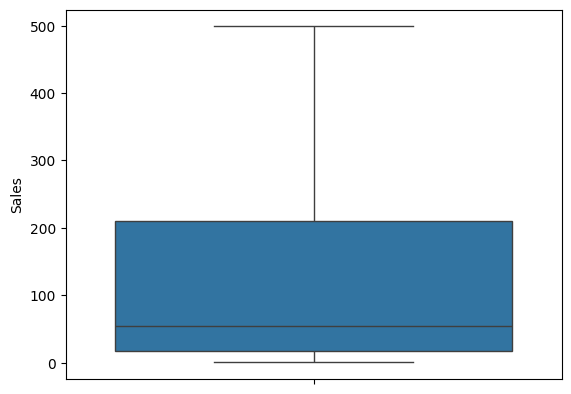

In [220]:
#Capping method for outlier removel
newdf=df.copy()
Q1=newdf["Sales"].quantile(0.25)
Q3=newdf["Sales"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
newdf=newdf.copy()
newdf.loc[newdf["Sales"]>upper_limit,'Sales']=upper_limit
newdf.loc[newdf["Sales"]<=lower_limit,'Sales']=lower_limit
sns.boxplot(newdf["Sales"])


In [195]:
#Z score to detect outlier
mean=df["Profit"].mean()
std=df["Profit"].std()
upper_limit=mean+3*std
lower_limit=mean-3*std
outlier=df.loc[(df["Profit"]>upper_limit)|(df["Profit"]<lower_limit)]
print(len(outlier))

107


9762


<Axes: xlabel='Profit'>

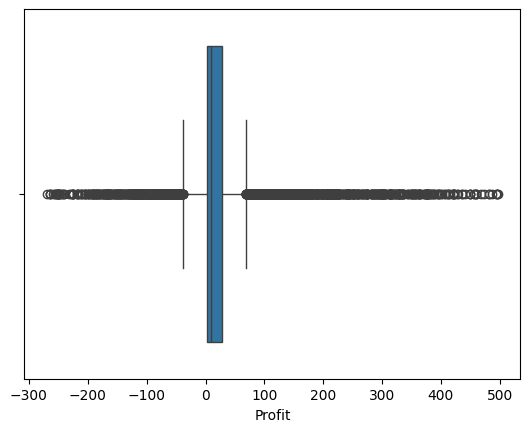

In [210]:
newdf=df.loc[(df["Profit"]>lower_limit)&(df["Profit"]<upper_limit)]
print(len(newdf))
sns.boxplot(x="Profit",data=newdf)

In [211]:
#IQR method outlier detection
Q1=df["Profit"].quantile(0.25)
Q3=df["Profit"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
total=df.loc[(df["Profit"]>=upper_limit)&(df["Profit"]<=lower_limit)]
print(len(total))

0


In [212]:
newdf=df.loc[(df["Profit"]<upper_limit)|(df["Profit"]>lower_limit)]
print(len(newdf))

9994


<Axes: ylabel='Profit'>

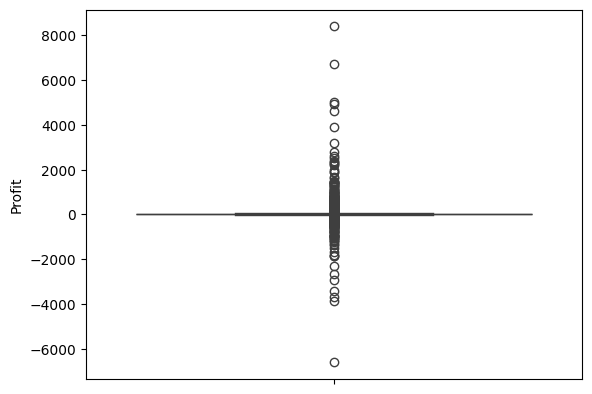

In [213]:
sns.boxplot(newdf["Profit"])

## outlier removed in Profit column

<Axes: ylabel='Profit'>

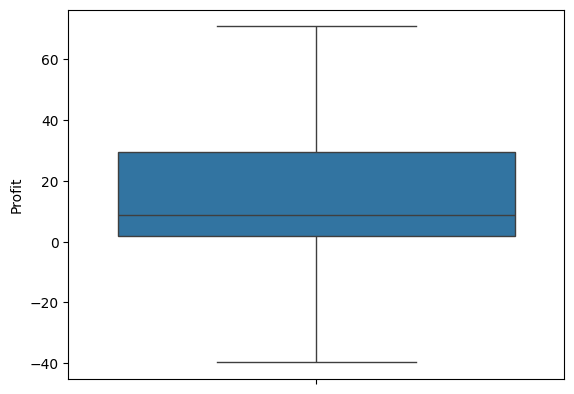

In [221]:
#Capping method for outlier removel
Q1=newdf["Profit"].quantile(0.25)
Q3=newdf["Profit"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
new=df.copy()
newdf.loc[newdf["Profit"]>upper_limit,'Profit']=upper_limit
newdf.loc[newdf["Profit"]<=lower_limit,'Profit']=lower_limit
sns.boxplot(newdf["Profit"])

<Axes: >

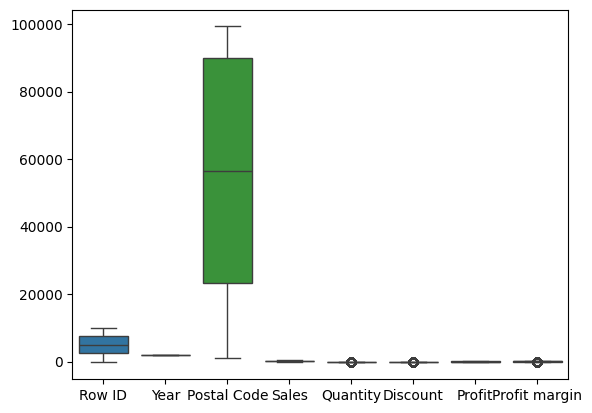

In [222]:
#outlier removed in Sales Profit column
sns.boxplot(data=newdf)


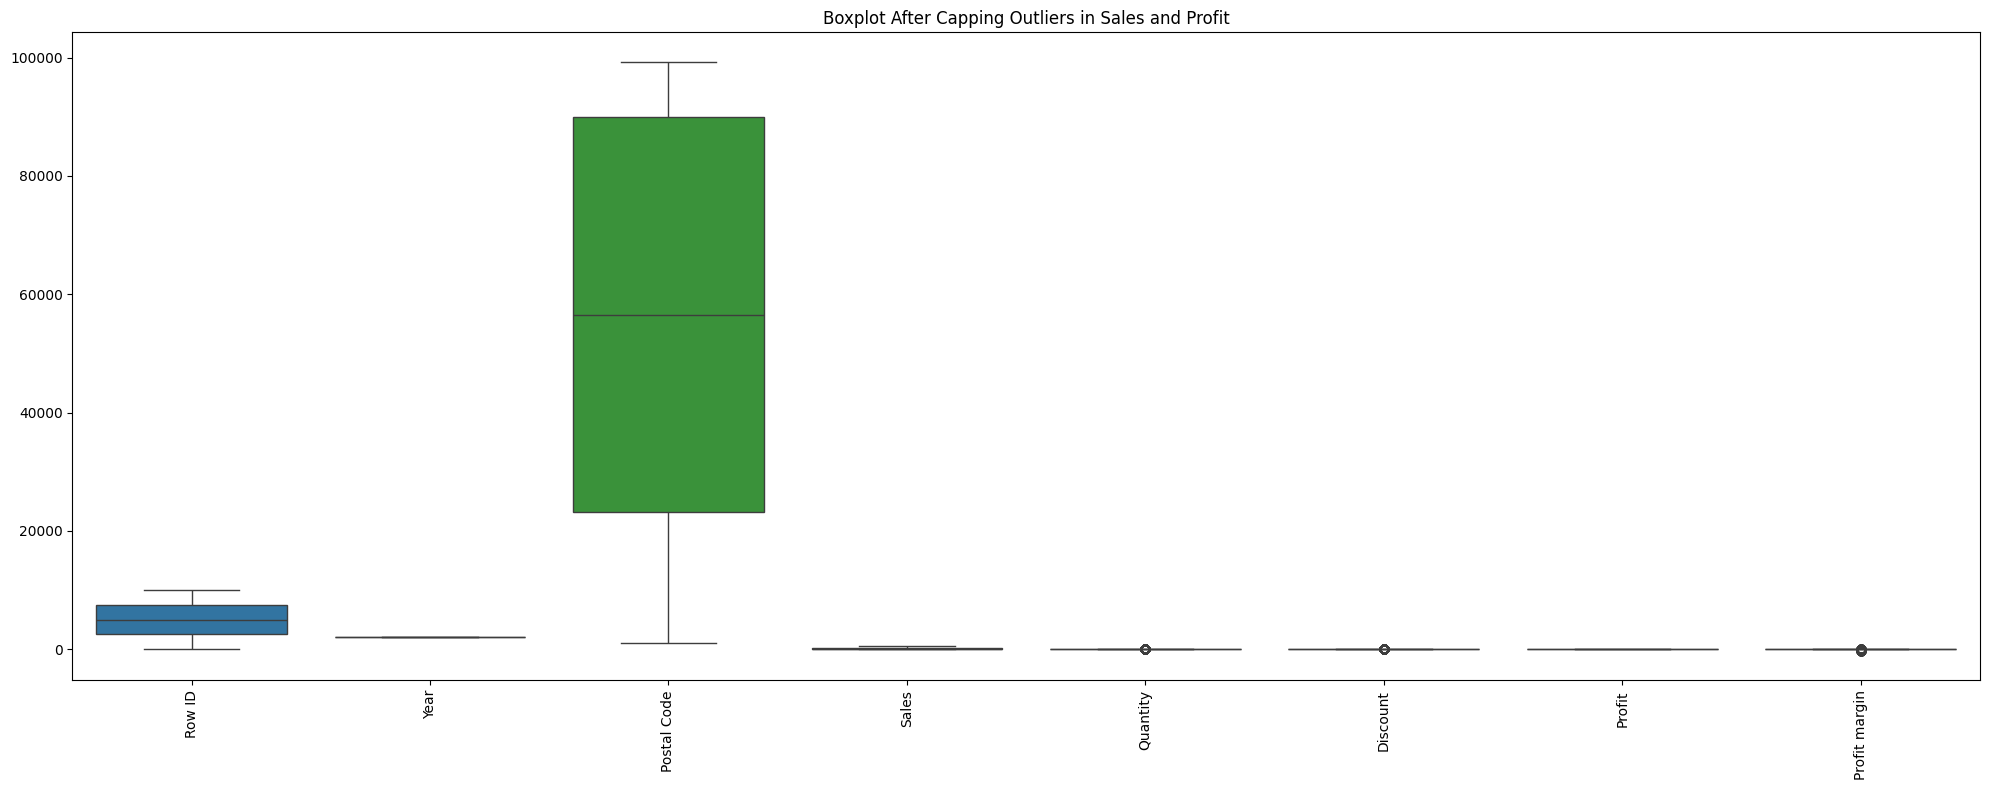

In [223]:

df_capped = df.copy()


Q1 = df_capped["Profit"].quantile(0.25)
Q3 = df_capped["Profit"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_capped.loc[df_capped["Profit"] > upper_limit, "Profit"] = upper_limit
df_capped.loc[df_capped["Profit"] < lower_limit, "Profit"] = lower_limit

# 3. Capping Sales
Q1 = df_capped["Sales"].quantile(0.25)
Q3 = df_capped["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_capped.loc[df_capped["Sales"] > upper_limit, "Sales"] = upper_limit
df_capped.loc[df_capped["Sales"] < lower_limit, "Sales"] = lower_limit

plt.figure(figsize=(20, 8))
sns.boxplot(data=df_capped)
plt.xticks(rotation=90)
plt.title("Boxplot After Capping Outliers in Sales and Profit")
plt.tight_layout()
plt.show()


# Corretion

In [122]:
#correlation: Measures the strength and direction of a linear relationship
numeric_cols=df.select_dtypes(['number'])
correlation=numeric_cols.corr()
print(correlation)

                 Row ID      Year  Postal Code     Sales  Quantity  Discount  \
Row ID         1.000000  0.015160     0.009671 -0.001359 -0.004016  0.013480   
Year           0.015160  1.000000     0.004539 -0.009800 -0.005788 -0.002615   
Postal Code    0.009671  0.004539     1.000000 -0.023854  0.012761  0.058443   
Sales         -0.001359 -0.009800    -0.023854  1.000000  0.200795 -0.028190   
Quantity      -0.004016 -0.005788     0.012761  0.200795  1.000000  0.008623   
Discount       0.013480 -0.002615     0.058443 -0.028190  0.008623  1.000000   
Profit         0.012497  0.004618    -0.029961  0.479064  0.066253 -0.219487   
Profit margin -0.020355  0.000147    -0.064404  0.003444 -0.005280 -0.864452   

                 Profit  Profit margin  
Row ID         0.012497      -0.020355  
Year           0.004618       0.000147  
Postal Code   -0.029961      -0.064404  
Sales          0.479064       0.003444  
Quantity       0.066253      -0.005280  
Discount      -0.219487      -0.8

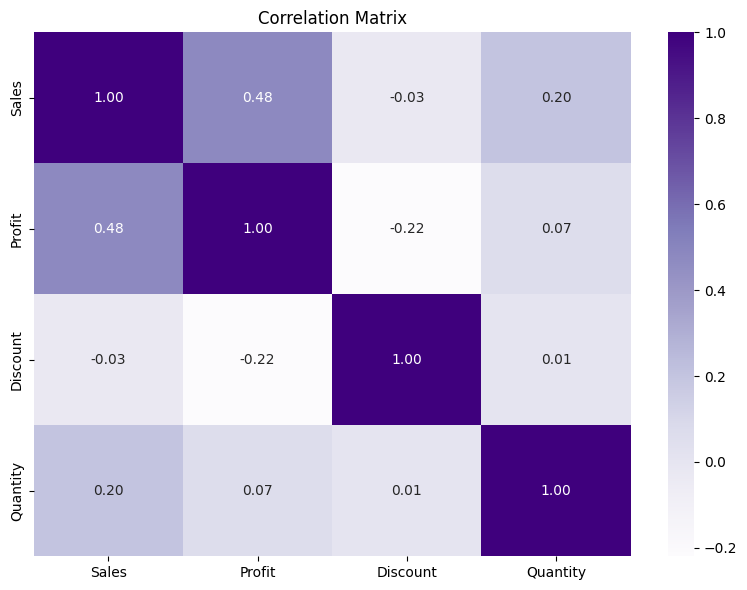

In [123]:
numeric_df = df[["Sales", "Profit", "Discount", "Quantity"]]
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="Purples")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [128]:
#covariance: Measures how two variables change together
covariance = numeric_cols.cov()
print(covariance)


                     Row ID        Year   Postal Code          Sales  \
Row ID         8.324169e+06   49.163264  8.946577e+05   -2442.819776   
Year           4.916326e+01    1.263465  1.635782e+02      -6.865173   
Postal Code    8.946577e+05  163.578168  1.028080e+09 -476682.766590   
Sales         -2.442820e+03   -6.865173 -4.766828e+05  388434.455308   
Quantity      -2.578260e+01   -0.014477  9.104159e+02     278.459923   
Discount       8.029358e+00   -0.000607  3.868704e+02      -3.627228   
Profit         8.446585e+03    1.216042 -2.250458e+05   69944.096586   
Profit margin -2.741115e+03    0.007733 -9.638591e+04     100.187720   

                 Quantity    Discount         Profit  Profit margin  
Row ID         -25.782598    8.029358    8446.585421   -2741.115192  
Year            -0.014477   -0.000607       1.216042       0.007733  
Postal Code    910.415885  386.870404 -225045.849445  -96385.909186  
Sales          278.459923   -3.627228   69944.096586     100.187720  
Q

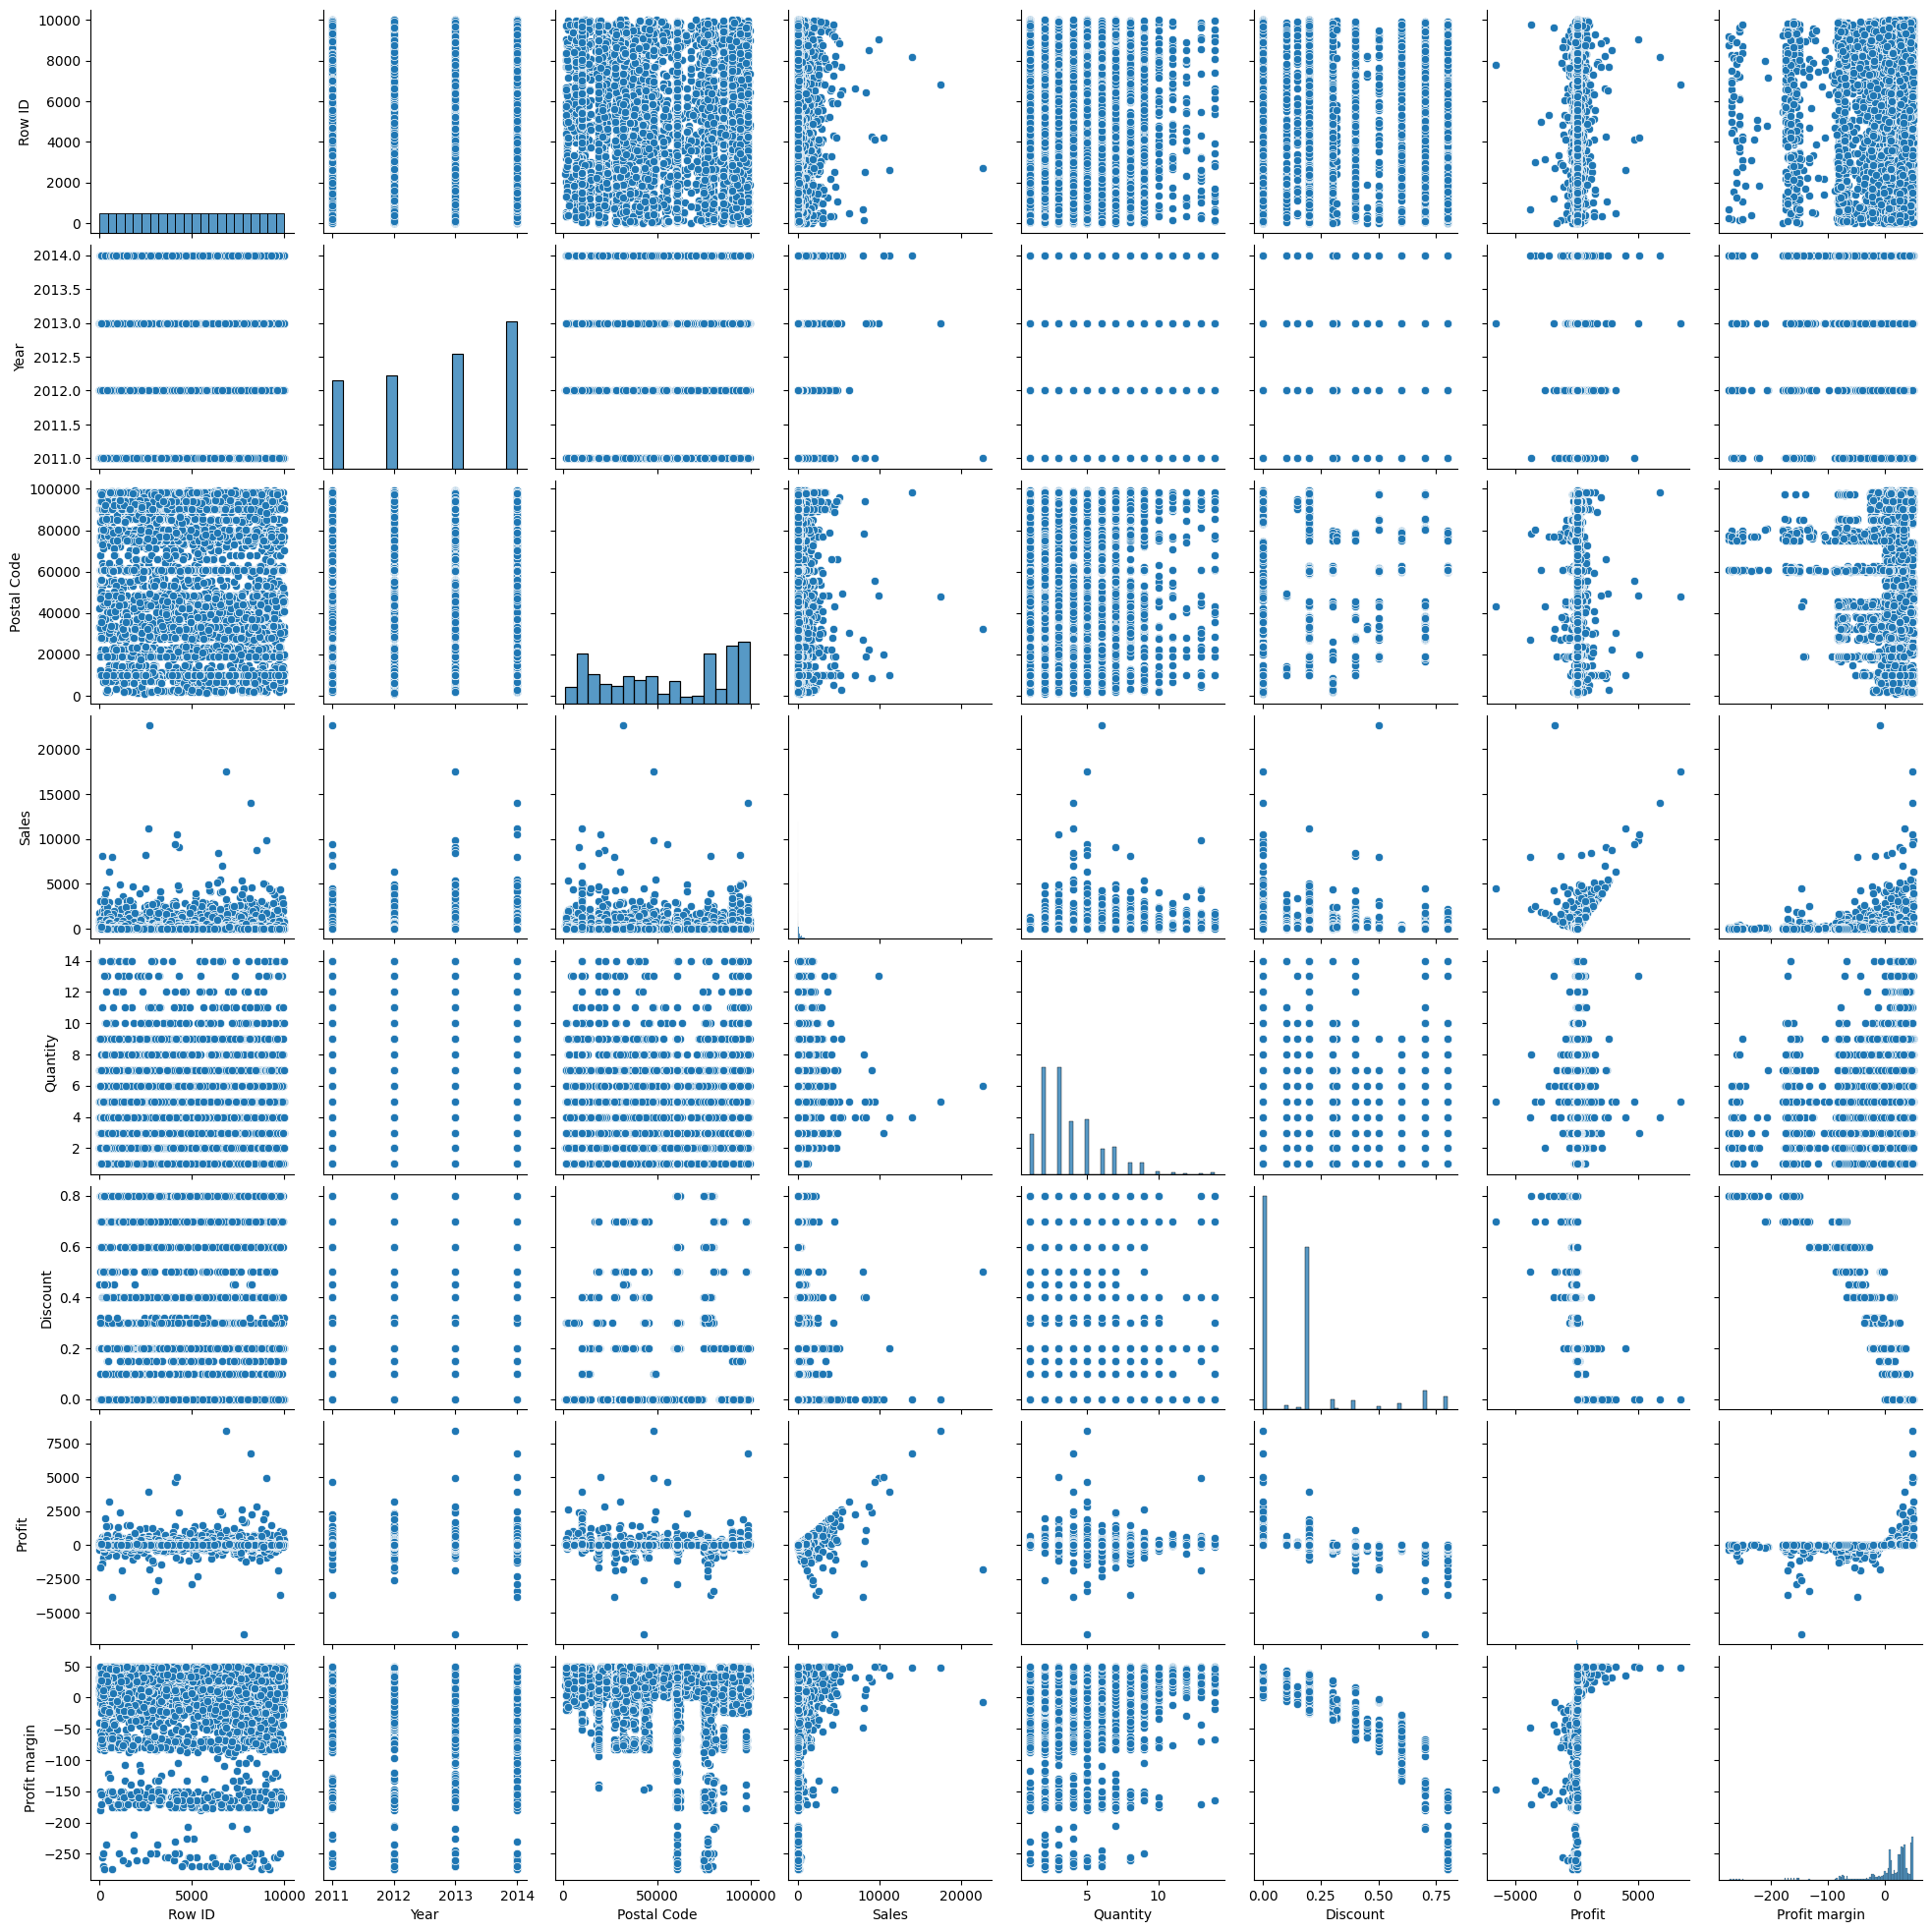

In [132]:
numeric=df.select_dtypes(['number'])
sns.pairplot(data=numeric)

C:\Users\admin\AppData\Local\Temp\ipykernel_1396\99099598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_sale.index, y=total_sale.values, palette="viridis")


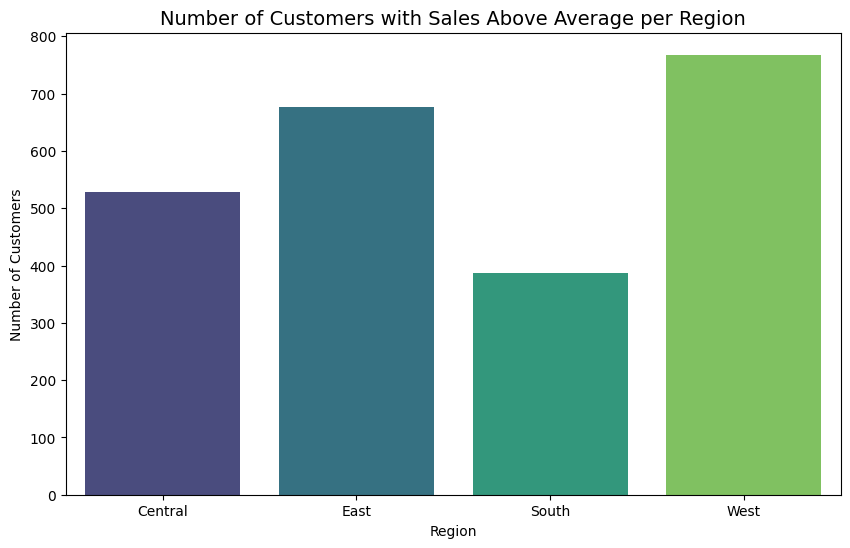

In [31]:
total_sale=project[project["Sales"]>average].groupby("Region").size()
plt.figure(figsize=(10, 6))
sns.barplot(x=total_sale.index, y=total_sale.values, palette="viridis")
plt.title("Number of Customers with Sales Above Average per Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_1396\1237434745.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='viridis')


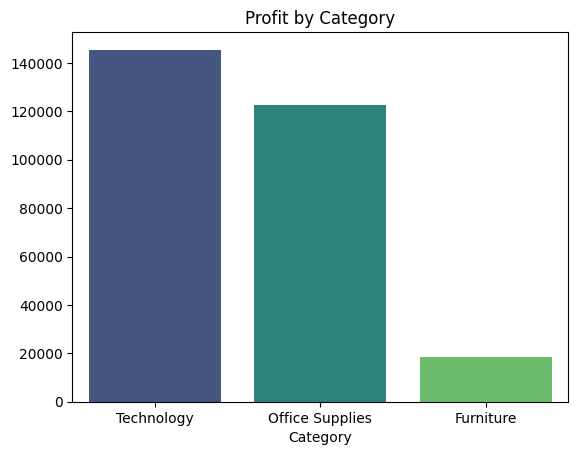

C:\Users\admin\AppData\Local\Temp\ipykernel_1396\1237434745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_category.index, y=sub_category.values, palette='plasma')


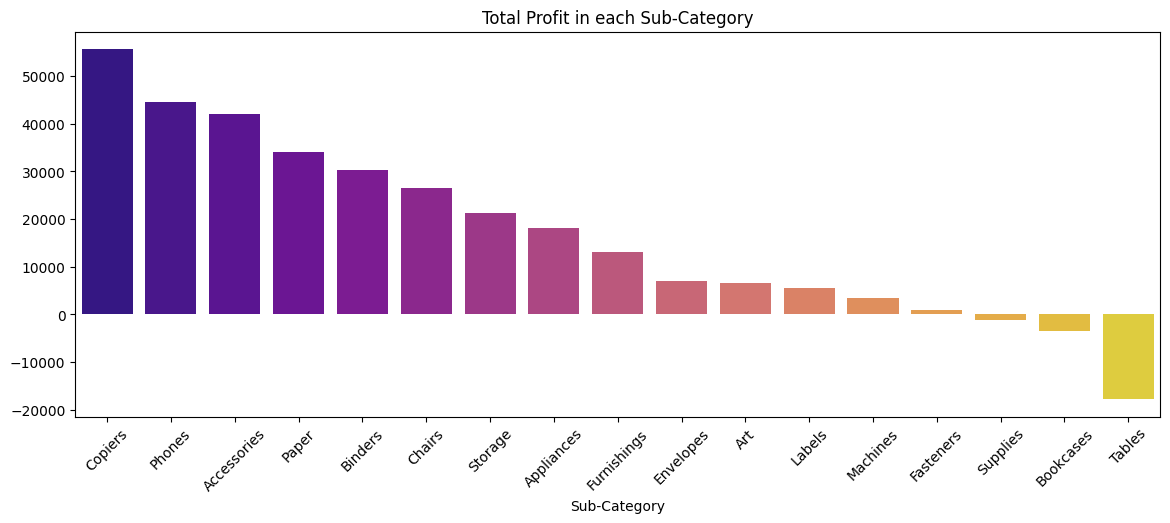

In [32]:
sns.barplot(x=category_profit.index, y=category_profit.values, palette='viridis')
plt.title('Profit by Category')
plt.show()

plt.figure(figsize=(14, 5))
sns.barplot(x=sub_category.index, y=sub_category.values, palette='plasma')
plt.title('Total Profit in each Sub-Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:

sns.barplot(x="Sales",y="Profit",data=df,hue="Region")
plt.title("Relation ship between Sales and Profit in each Region")

In [35]:
sale=df.groupby("State")["Sales"].sum().sort_values()
print(sale)

State
North Dakota               919.9100
West Virginia             1209.8240
Maine                     1270.5300
South Dakota              1315.5600
Wyoming                   1603.1360
District of Columbia      2865.0200
Kansas                    2914.3100
Idaho                     4382.4860
Iowa                      4579.7600
New Mexico                4783.5220
Montana                   5589.3520
New Hampshire             7292.5240
Nebraska                  7464.9300
South Carolina            8481.7100
Vermont                   8929.3700
Louisiana                 9217.0300
Mississippi              10771.3400
Utah                     11220.0560
Arkansas                 11678.1300
Connecticut              13384.3570
Nevada                   16729.1020
Oregon                   17431.1500
Alabama                  19510.6400
Oklahoma                 19683.3900
Missouri                 22205.1500
Rhode Island             22627.9560
Maryland                 23705.5230
Delaware              

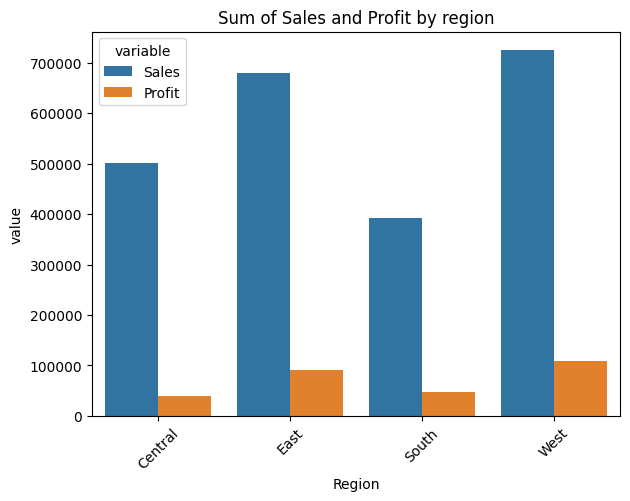

In [69]:
summary = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index().melt(id_vars="Region")

# Plot
sns.barplot(x="Region", y="value", hue="variable", data=summary)
plt.title("Sum of Sales and Profit by region")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

              Profit        Sales
Region                           
Central   39706.3625  501239.8908
East      91522.7800  678781.2400
South     46749.4303  391721.9050
West     108418.4489  725457.8245


Text(0.5, 1.0, 'Total Profit in each region')

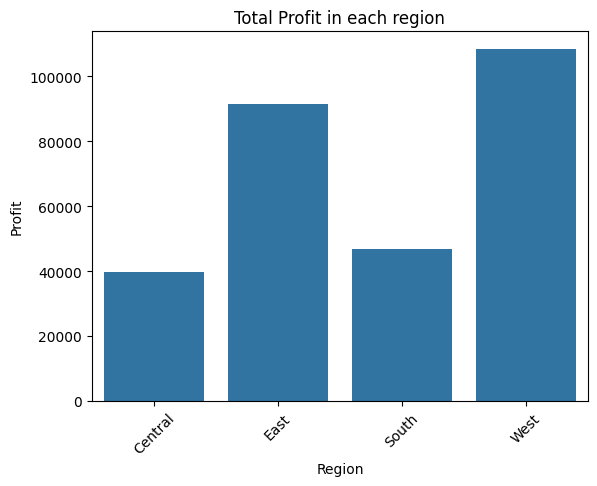

In [70]:
sale=df.groupby("Region")[["Profit","Sales"]].sum()
print(sale)
sale_df=sale.reset_index()
sns.barplot(x="Region",y="Profit",data=sale_df)
plt.xticks(rotation=45)
plt.title("Total Profit in each region")

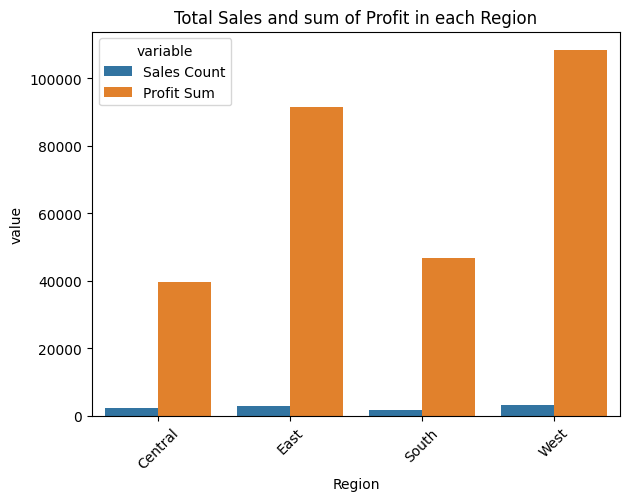

In [135]:
summary = df.groupby("Region")[["Sales", "Profit"]].agg({
    "Sales": "count",   # Number of sales
    "Profit": "sum"     # Total profit
}).reset_index()

# Rename columns for clarity
summary.columns = ["Region", "Sales Count", "Profit Sum"]

# Melt for plotting
summary = summary.melt(id_vars="Region")

# Plot
sns.barplot(x="Region", y="value", hue="variable", data=summary)
plt.title("Total Sales and sum of Profit in each Region")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

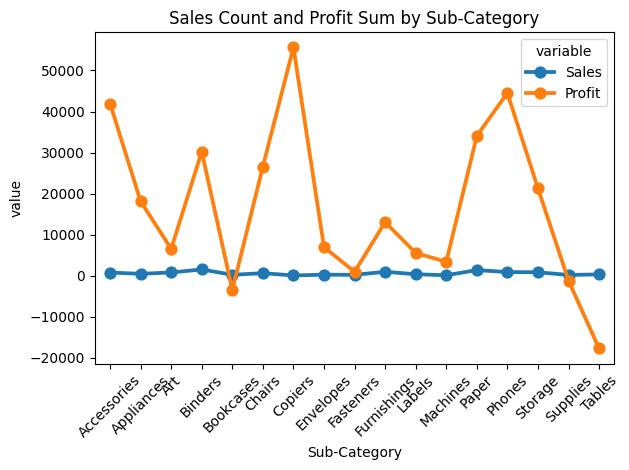

In [72]:
sale=df.groupby("Sub-Category")[["Sales","Profit"]].agg({"Sales":"count","Profit":"sum"}).reset_index().melt(id_vars="Sub-Category")
sns.pointplot(x="Sub-Category", y="value", hue="variable", data=sale)
plt.title("Sales Count and Profit Sum by Sub-Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Total Sales Profit and Quanityin each year')

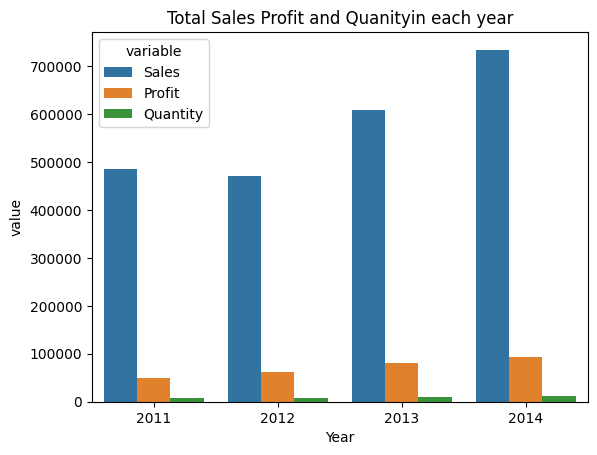

In [116]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract year
df["Year"] = df["Order Date"].dt.year
total=df.groupby("Year")[["Sales","Profit","Quantity"]].agg({"Sales":"sum","Profit":"sum","Quantity":"sum"}).reset_index().melt(id_vars="Year")
sns.barplot(x="Year",y="value",hue="variable",data=total)
plt.title("Total Sales Profit and Quanityin each year")

([0, 1, 2, 3],
 [Text(0, 0, '2011'),
  Text(1, 0, '2012'),
  Text(2, 0, '2013'),
  Text(3, 0, '2014')])

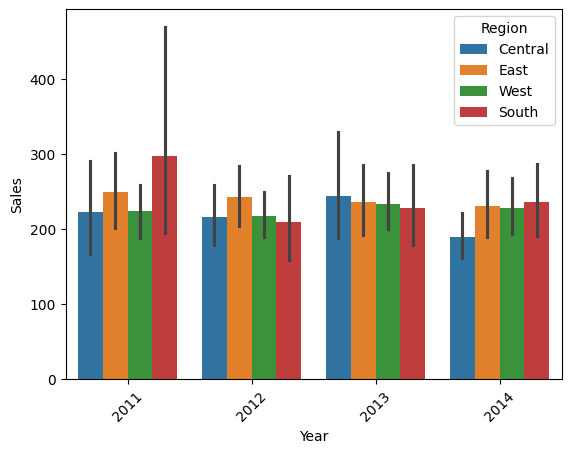

In [86]:

sns.barplot(x="Year",y="Sales",data=df,hue="Region")
plt.xticks(rotation=45)

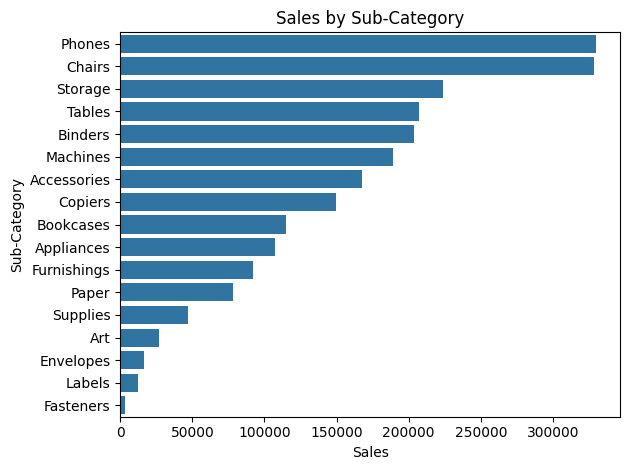

In [84]:
subcat = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).reset_index()
sns.barplot(x="Sales", y="Sub-Category", data=subcat)
plt.title("Sales by Sub-Category")
plt.tight_layout()
plt.show()


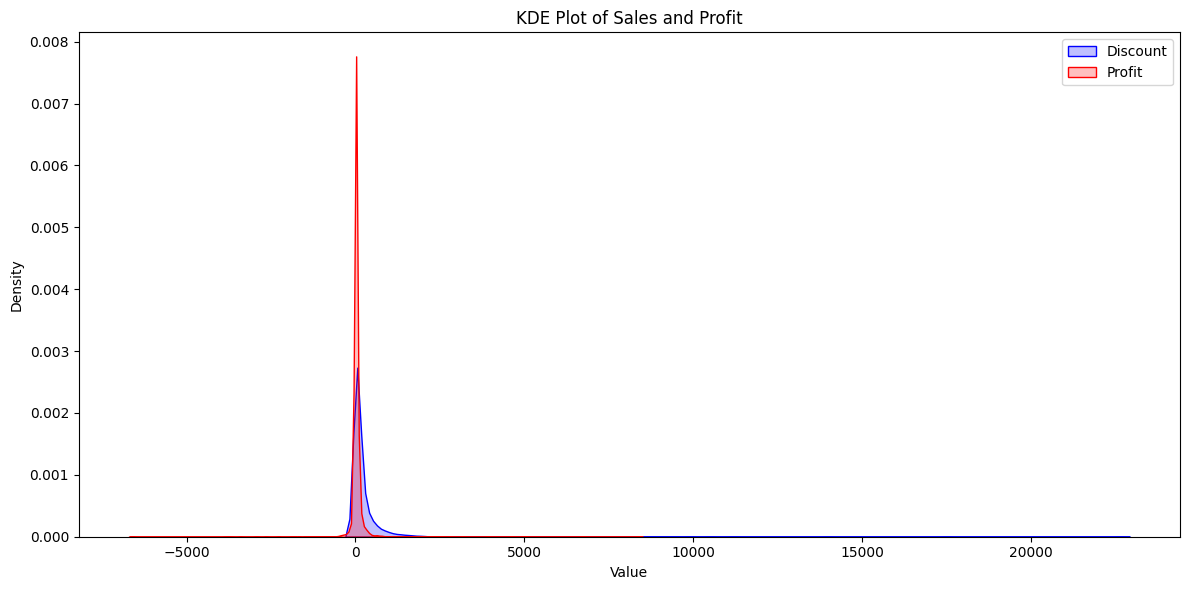

In [103]:
#if discount increase the sales profit also increase
plt.figure(figsize=(12,6))
sns.kdeplot(data=df, x="Sales", label="Discount", fill=True, color='blue')
sns.kdeplot(data=df, x="Profit", label="Profit", fill=True, color='red')

plt.title("KDE Plot of Sales and Profit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

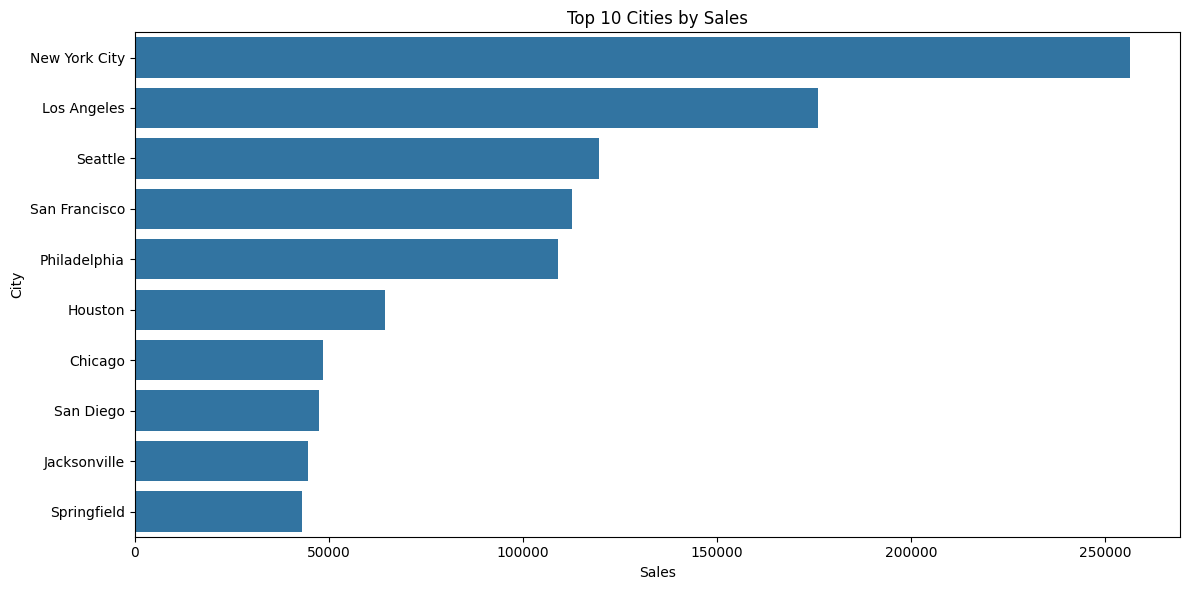

In [93]:
plt.figure(figsize=(12, 6))
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="Sales", y="City", data=top_cities)
plt.title("Top 10 Cities by Sales")
plt.tight_layout()
plt.show()


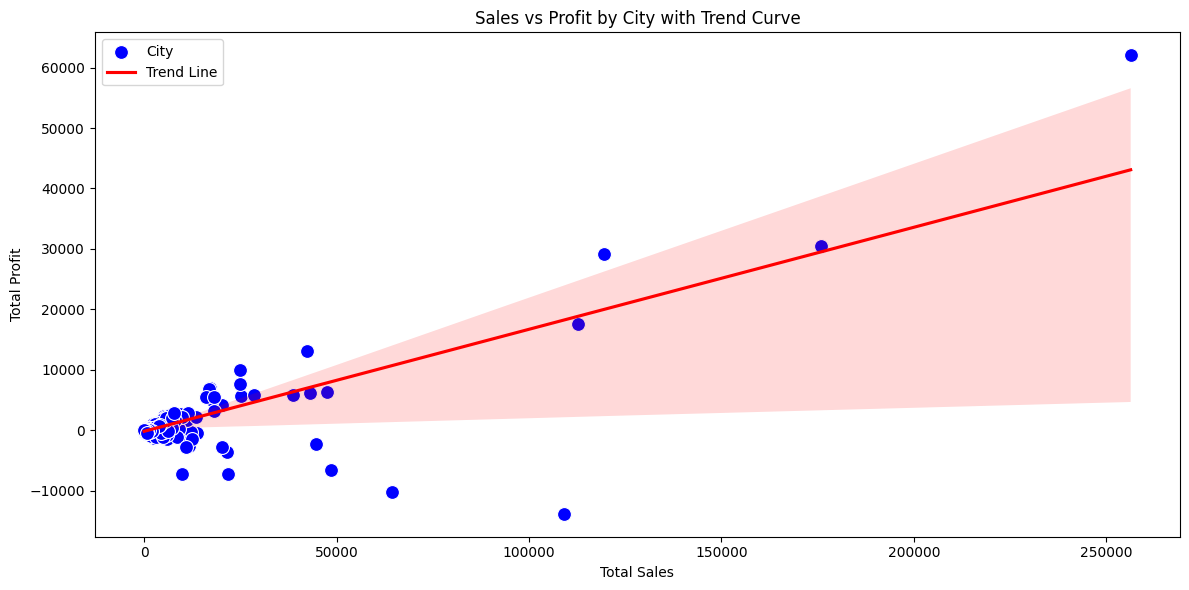

In [95]:

city_summary = df.groupby("City")[["Sales", "Profit"]].sum().reset_index()

# Plot with scatter + regression curve
plt.figure(figsize=(12, 6))
sns.scatterplot(data=city_summary, x="Sales", y="Profit", s=100, color='blue', label='City')
sns.regplot(data=city_summary, x="Sales", y="Profit", scatter=False, color='red', label='Trend Line')

plt.title("Sales vs Profit by City with Trend Curve")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.legend()
plt.tight_layout()
plt.show()


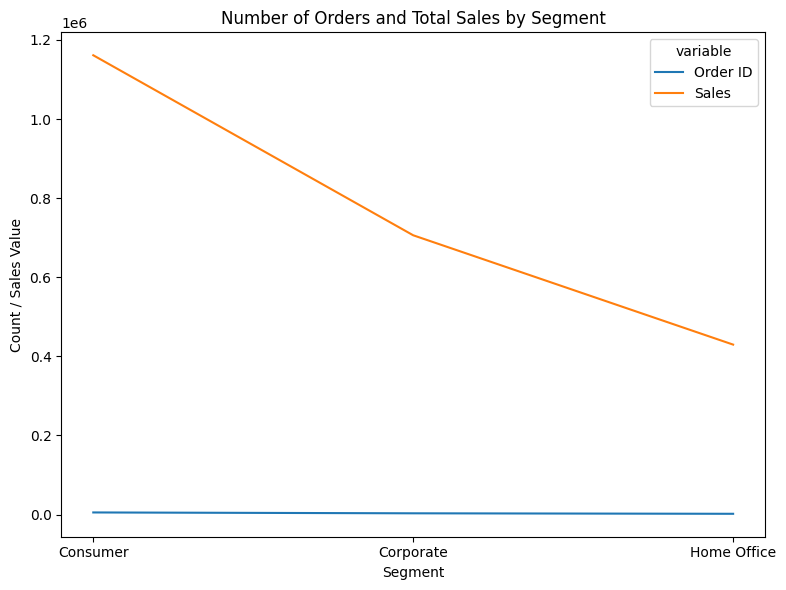

In [110]:
#total orders in each segment
top=df.groupby("Segment")[["Order ID","Sales"]].agg({"Order ID":"count","Sales":"sum"}).reset_index().melt(id_vars="Segment")
plt.figure(figsize=(8, 6))
sns.lineplot(data=top, x="Segment", y="value", hue="variable")

plt.title("Number of Orders and Total Sales by Segment")
plt.ylabel("Count / Sales Value")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Profit and Quantity')

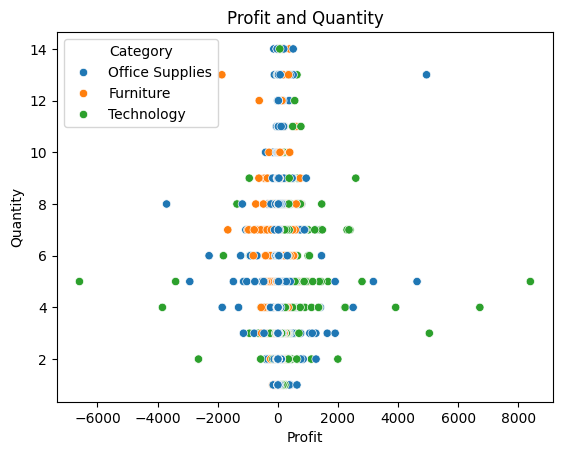

In [143]:

sns.scatterplot(x="Profit",y="Quantity",data=df,hue="Category")
plt.title("Profit and Quantity")

array([[<Axes: title={'center': 'Row ID'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Order Date'}>],
       [<Axes: title={'center': 'Ship Date'}>,
        <Axes: title={'center': 'Postal Code'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'Discount'}>,
        <Axes: title={'center': 'Profit'}>],
       [<Axes: title={'center': 'Profit margin'}>, <Axes: >, <Axes: >]],
      dtype=object)

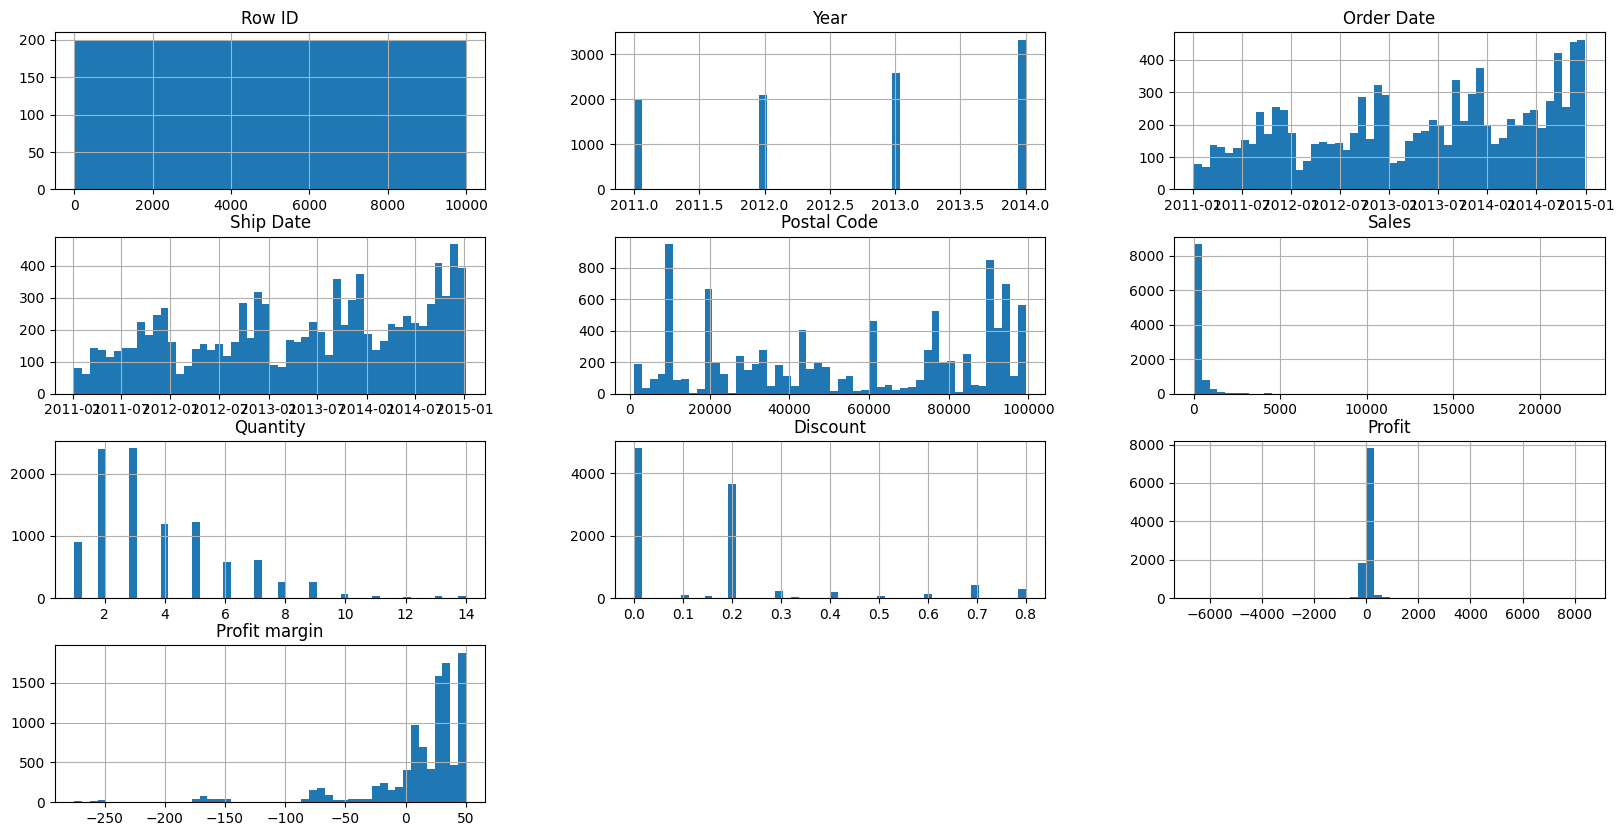

In [117]:
df.hist(bins=50,figsize=(20,10))

Text(0.5, 1.0, 'KDE Plot of Sales by Year')

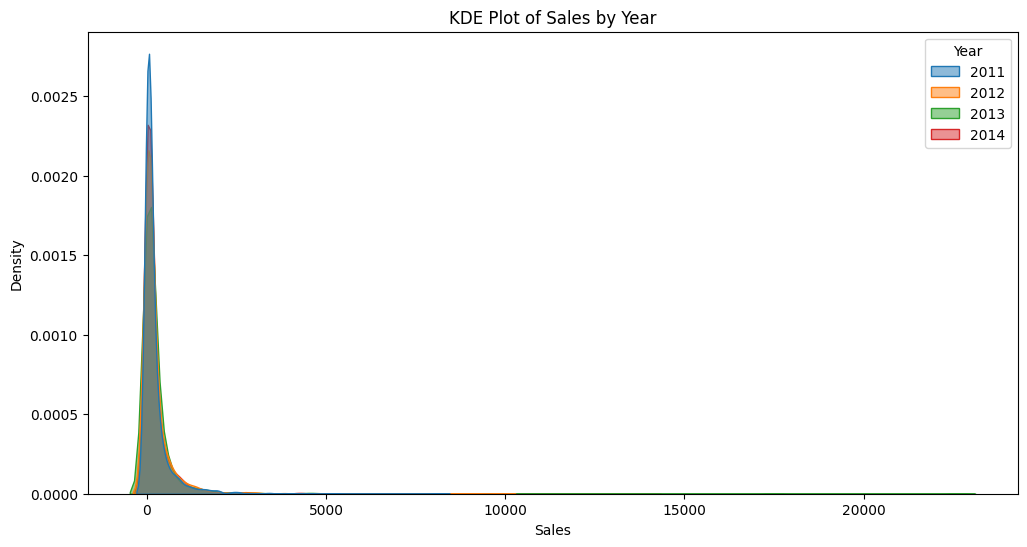

In [225]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="Sales", hue="Year", fill=True, common_norm=False, palette="tab10", alpha=0.5)
plt.title("KDE Plot of Sales by Year")